In [1]:
import os
import glob
import pandas as pd
import rasterio as rio
from tqdm import tqdm
import numpy as np
import leafmap
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

In [2]:
path = 'data'

os.listdir(path)

['train_answer.csv',
 'sample_answer.csv',
 'README.md',
 'test_images',
 'train_images']

In [3]:
train_images = glob.glob(path + '/train_images/*.tif')
test_images = glob.glob(path + '/test_images/*.tif')

print('Number of train images:', len(train_images))
print('Number of test images:', len(test_images))

Number of train images: 4465
Number of test images: 1489


We have 4465 training images, with location name and AOD. 

In [4]:
train_answer = pd.read_csv(path + '/train_answer.csv', names=['image', 'location', 'AOD'])	
train_answer

,image,location,AOD
0,train_1.tif,Camaguey,0.041617
1,train_2.tif,Pontianak,0.187255
2,train_3.tif,Hong_Kong_Sheung,0.214568
3,train_4.tif,Beijing-CAMS,0.084528
4,train_5.tif,ATHENS_NTUA,0.085251
...,...,...,...
4460,train_4461.tif,Beijing,0.357386
4461,train_4462.tif,Pontianak,0.127051
4462,train_4463.tif,Gangneung_WNU,0.768371
4463,train_4464.tif,MD_Science_Center,0.077829


In [5]:
train_answer.describe()

,AOD
count,4465.000000
mean,0.209845
std,0.224224
min,0.003571
25%,0.073370
50%,0.133372
75%,0.257629
max,2.860874


The goal is to provide AOD for 1489 test images.

In [6]:
sample_answer = pd.read_csv(path + '/sample_answer.csv', names=['image', 'AOD'])
sample_answer

,image,AOD
0,test_1.tif,1.442470
1,test_2.tif,0.910374
2,test_3.tif,0.500745
3,test_4.tif,0.999882
4,test_5.tif,1.668206
...,...,...
1484,test_1485.tif,1.597977
1485,test_1486.tif,1.819262
1486,test_1487.tif,1.334963
1487,test_1488.tif,0.231196


In [7]:
train_images[:3]

['data/train_images/train_546.tif',
 'data/train_images/train_3939.tif',
 'data/train_images/train_2424.tif']

In [8]:
image = rio.open(train_images[0])
image.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': -9999.0,
 'width': 128,
 'height': 128,
 'count': 13,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.0002331731549529703, 0.0, 116.30177085143507,
        0.0, -0.0001799427429129974, 39.94484854841792)}

In [9]:
def check_images(images):
	hs, ws, cs = [], [], []
	dts, mins, maxs = [], [], []
	for image in tqdm(images):
		img = rio.open(image)
		h, w = img.shape[:2]
		hs.append(h)
		ws.append(w)
		cs.append(img.count)
		x = img.read()
		if not x.dtype in dts:
			dts.append(x.dtype)
		mins.append(x.min())
		maxs.append(x.max())
	return {
		'height': np.unique(hs),
		'width': np.unique(ws),
		'channel': np.unique(cs),
		'min': np.min(mins),
		'max': np.max(maxs),
		'dtype': dts
	}

In [10]:
# check_images(train_images)

100%|██████████| 4465/4465 [00:55<00:00, 80.39it/s]


{'height': array([128]),
 'width': array([128]),
 'channel': array([13]),
 'min': -9999.0,
 'max': 2.8003,
 'dtype': [dtype('float32')]}

In [11]:
# check_images(test_images)

All images are 128x128 pixels and have 13 bands.

In [12]:
x = rio.open(train_images[4]).read()

x.shape, x.dtype, x.min(), x.max()

((13, 128, 128), dtype('float32'), -9999.0, 1.2156)

Image are float32 with values between 0 and 2.8, looks like they are already normalized.

OJO !!! no data values are set to -9999 (will need to set to 0 or something).

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


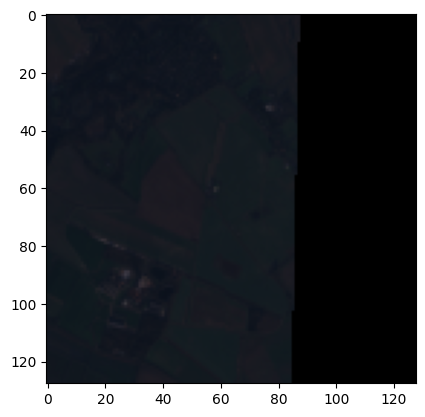

In [13]:
rgb = x[(3,2,1), ...]

plt.imshow(rgb.transpose(1,2,0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

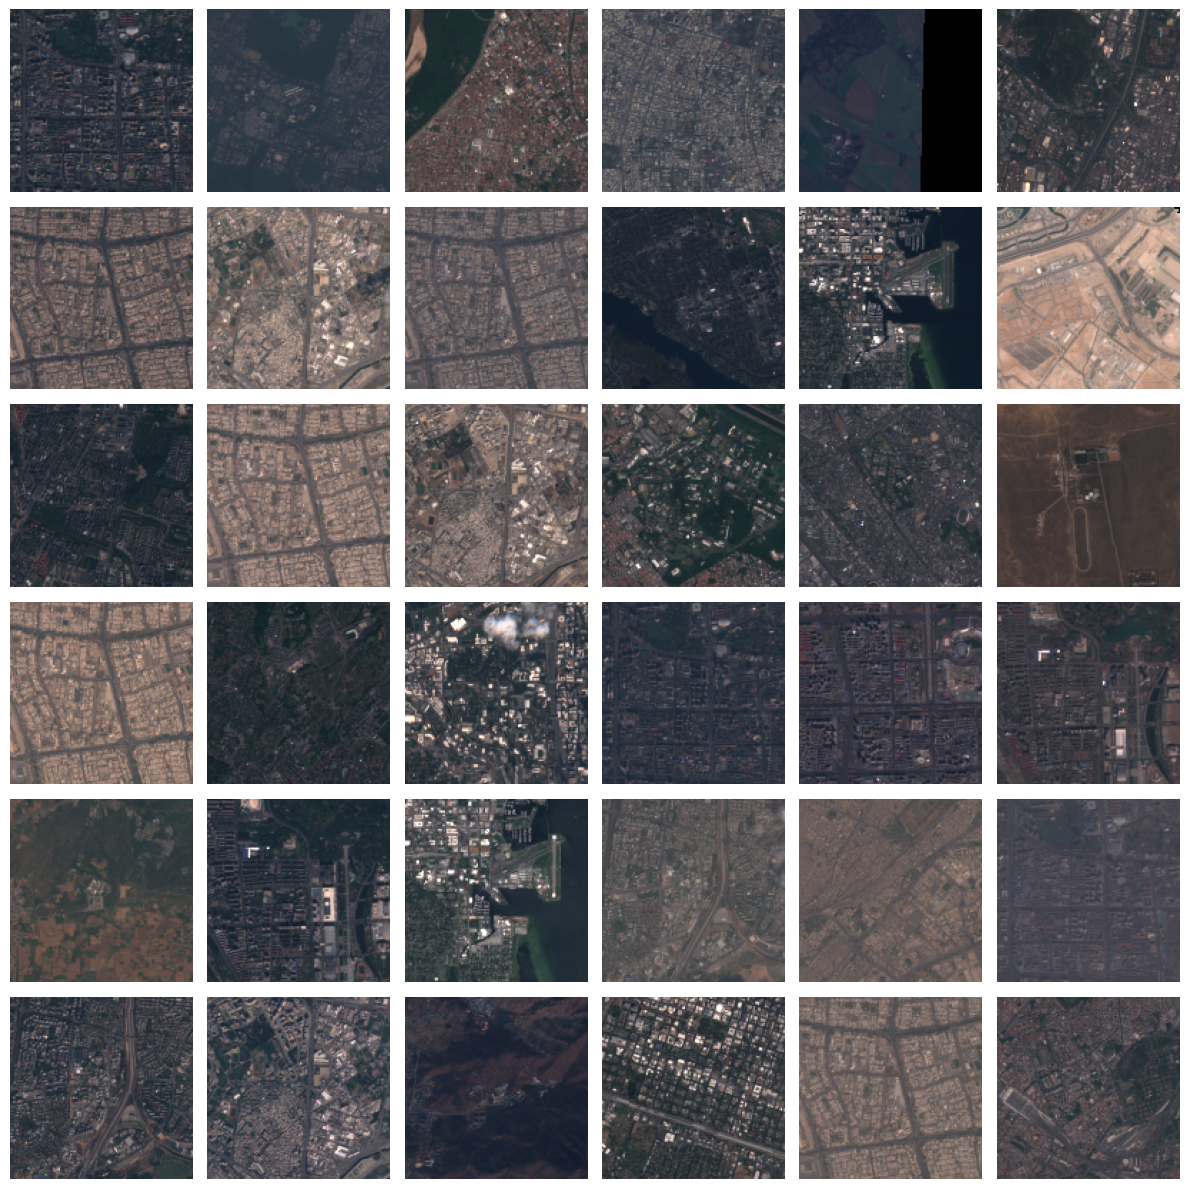

In [14]:
rows, cols = 6, 6
fig, axs = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
for i, ax in enumerate(axs.flat):
	image = rio.open(train_images[i])
	x = image.read()
	rgb = x[(3,2,1), ...]
	ax.imshow(rgb.transpose(1,2,0) * 2)
	ax.axis('off')
plt.tight_layout()
plt.show()

Do we have lat, lng ?

In [15]:
image = rio.open(test_images[10])

image.bounds, image.crs

(BoundingBox(left=10.185506109022459, bottom=36.827204877403304, right=10.214101694600998, top=36.85023754841792),
 CRS.from_epsg(4326))

In [16]:
bbox = image.bounds
bbox_geom = box(*bbox)
gdf = gpd.GeoDataFrame({"geometry": [bbox_geom]}, crs="EPSG:4326")
m = leafmap.Map(center=[(bbox.bottom + bbox.top) / 2, (bbox.left + bbox.right) / 2], zoom=10)
m.add_gdf(gdf, layer_name="Bounding Box")
m

Map(center=[36.83872121291061, 10.199803901811729], controls=(ZoomControl(options=['position', 'zoom_in_text',…

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


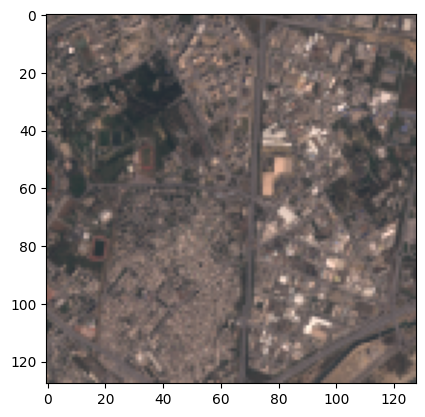

In [17]:
x = image.read()
rgb = x[(3,2,1), ...]

plt.imshow(rgb.transpose(1,2,0) * 2)
plt.show()

Looks like it !

Tenemos fecha de adquisición ?

In [24]:
image.tags()

{'AREA_OR_POINT': 'Area'}

Parece que no :(